## Topic

Volatility Forecasting; Out-of-Sample Evaluation

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/volatility-forecasting-out-of-sample-evaluation.html)。

## Question

What is Volatility Forecasting; Out-of-Sample Evaluation, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Volatility Forecasting; Out-of-Sample Evaluation

## Learning Goal

Use annualized root-mean-square daily returns: target(t)=sqrt(252*mean(r[t+1:t+6]^2)); baseline(t)=sqrt(252*mean(r[t-19:t+1]^2)). This defines realized RMS volatility without demeaning. Compare Ridge and baseline on identical dates.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Run the synthetic two-asset experiment. Change alpha only using walk-forward development folds, freeze it, then evaluate the locked final test once. Record when features and labels become available.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


development    alpha  origin       MAE
0    0.1     300  0.292826
1    0.1     360  0.094513
2    0.1     420  0.096930
3    1.0     300  0.292685
4    1.0     360  0.094541
5    1.0     420  0.096893
6   10.0     300  0.291306
7   10.0     360  0.094802
8   10.0     420  0.096534 selected 10.0
past20 MAE 0.1194534613858229 RMSE 0.1462085683358439
ridge MAE 0.11234968643638735 RMSE 0.1363407899725345
ETF_A_SYNTHETIC paired MAE delta -0.008508406894224014
ETF_B_SYNTHETIC paired MAE delta -0.005699143004647154


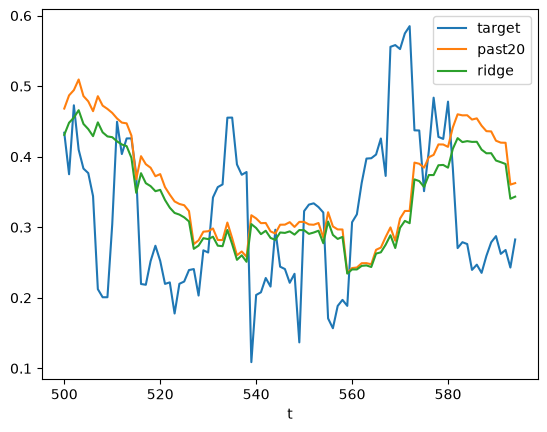

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error
rng=np.random.default_rng(7);n=600;frames=[]
for asset in ["ETF_A_SYNTHETIC","ETF_B_SYNTHETIC"]:
    r=rng.normal(size=n)*np.where(np.arange(n)<300,.01,.025)
    frame=pd.DataFrame({"t":np.arange(n),"asset":asset,"r":r})
    frame["past20"]=np.sqrt(252*pd.Series(r*r).rolling(20).mean())
    for lag in [0,1,2]:frame[f"abs_lag{lag}"]=pd.Series(abs(r)).shift(lag)
    frame["target"]=np.sqrt(252*sum(pd.Series(r*r).shift(-k) for k in range(1,6))/5)
    frame["label_end"]=frame.t+5;frames.append(frame.dropna())
data=pd.concat(frames,ignore_index=True);features=["past20","abs_lag0","abs_lag1","abs_lag2"]
rows=[]
for alpha in [.1,1.,10.]:
    for start in [300,360,420]:
        train=data[data.label_end<start];valid=data[(data.t>=start)&(data.t<start+40)]
        model=make_pipeline(StandardScaler(),Ridge(alpha=alpha)).fit(train[features],train.target)
        pred=np.maximum(model.predict(valid[features]),0)
        rows.append({"alpha":alpha,"origin":start,"MAE":mean_absolute_error(valid.target,pred)})
cv=pd.DataFrame(rows);selected=float(cv.groupby("alpha").MAE.mean().idxmin());print("development",cv,"selected",selected)
# Freeze configuration before opening the final block. Do not retune on its results.
train=data[data.label_end<500];test=data[data.t>=500].copy();assert train.label_end.max()<test.t.min()
model=make_pipeline(StandardScaler(),Ridge(alpha=selected)).fit(train[features],train.target)
test["ridge"]=np.maximum(model.predict(test[features]),0)
for name in ["past20","ridge"]:
    print(name,"MAE",mean_absolute_error(test.target,test[name]),"RMSE",np.sqrt(mean_squared_error(test.target,test[name])))
for asset,part in test.groupby("asset"):print(asset,"paired MAE delta",np.mean(abs(part.ridge-part.target)-abs(part.past20-part.target)))
test[test.asset=="ETF_A_SYNTHETIC"].plot(x="t",y=["target","past20","ridge"]);plt.show()
assert np.isfinite(test.ridge).all()

## Expected Observations

Ridge may lose to the historical baseline. These synthetic data validate mechanics only; they do not demonstrate ETF predictability or trading profitability. Re-running this lesson is instructional, not a fresh independent test.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. Use annualized root-mean-square daily returns: target(t)=sqrt(252*mean(r[t+1:t+6]^2)); baseline(t)=sqrt(252*mean(r[t-19:t+1]^2)). This defines realized RMS volatility without demeaning. Compare Ridge and baseline on identical dates.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Ridge may lose to the historical baseline. These synthetic data validate mechanics only; they do not demonstrate ETF predictability or trading profitability. Re-running this lesson is instructional, not a fresh independent test.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/volatility-forecasting-out-of-sample-evaluation.html)
